In [6]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [7]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,ff421_00000,0,0.488062,least_confidence,1,809.267885
1,1,ff421_00000,1,0.454841,least_confidence,1,809.267885
2,2,ff421_00000,2,0.477158,least_confidence,1,809.267885
3,3,ff421_00000,3,0.501733,least_confidence,1,809.267885
4,4,ff421_00000,4,0.479074,least_confidence,1,809.267885
...,...,...,...,...,...,...,...
22470,22470,ff421_00024,894,0.971605,random,5,786.125101
22471,22471,ff421_00024,895,0.973752,random,5,786.125101
22472,22472,ff421_00024,896,0.972080,random,5,786.125101
22473,22473,ff421_00024,897,0.968985,random,5,786.125101


In [8]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
17980,17980,ff421_00020,0,0.513361,random,1,761.331248
17981,17981,ff421_00020,1,0.481337,random,1,761.331248
17982,17982,ff421_00020,2,0.472910,random,1,761.331248
17983,17983,ff421_00020,3,0.543926,random,1,761.331248
17984,17984,ff421_00020,4,0.537365,random,1,761.331248
...,...,...,...,...,...,...,...
22470,22470,ff421_00024,894,0.971605,random,5,786.125101
22471,22471,ff421_00024,895,0.973752,random,5,786.125101
22472,22472,ff421_00024,896,0.972080,random,5,786.125101
22473,22473,ff421_00024,897,0.968985,random,5,786.125101


In [9]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{row.avg:.2f} ± {row.stdv:.2f}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

/var/folders/02/fbyrwz_s7tg4vmbm1kswhxp40000gp/T/ipykernel_29801/2952143151.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])


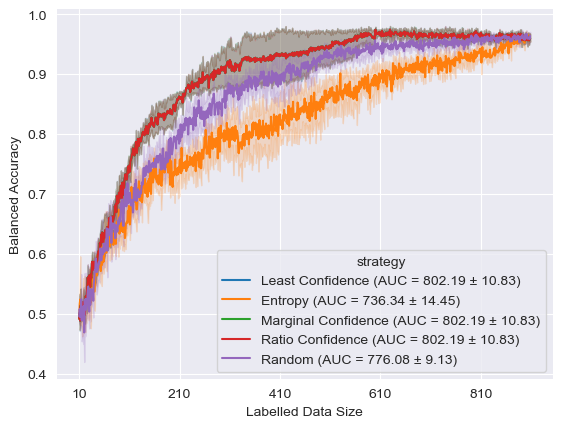

In [10]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Balanced Accuracy")
plt.xlabel("Labelled Data Size")

current_xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
    

for spine in ax.spines.values():
    spine.set_visible(False)